In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *
from triqs_tprf.lattice import lattice_dyson_g0_wk, lattice_dyson_g_wk, lindhard_chi00

import seaborn as sns
color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

Starting serial run at: 2026-05-05 17:21:18.265285


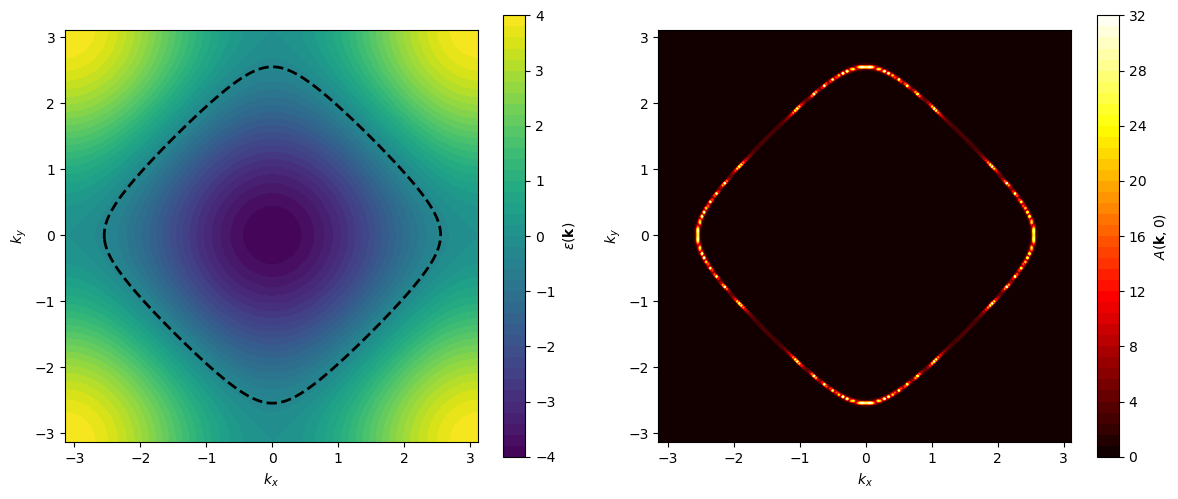

In [5]:
import numpy as np
import matplotlib.pyplot as plt

square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

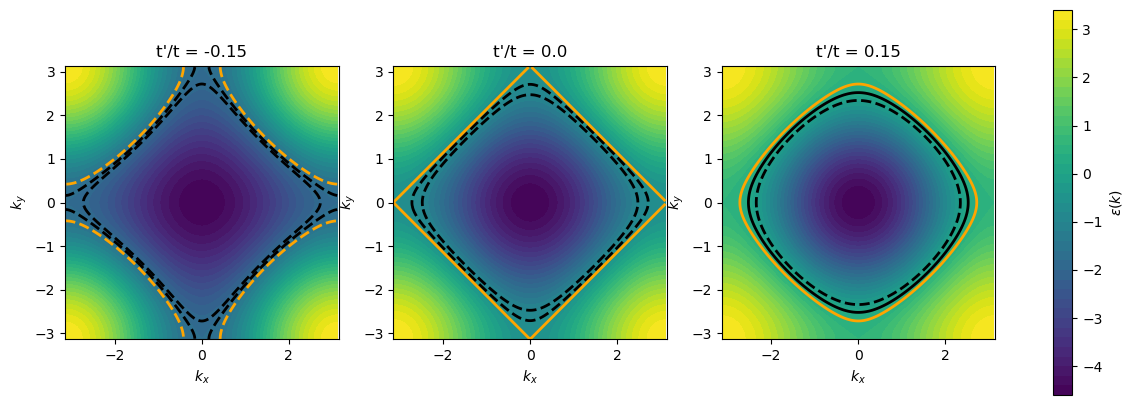

In [9]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.15, 0., 0.15]

nk = 200

k_mesh, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    
    square.get_e_k(nk)
    eps = square.e_k.data[:, 0, 0].real
    eps = eps.reshape(nk, nk)
    eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

    cf = ax.contourf(kx, ky, eps, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    ax.contour(kx, ky, eps, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, eps, levels=[mu_list[-1]], colors='orange', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


Starting serial run at: 2026-04-20 22:40:52.864629
Starting serial run at: 2026-04-20 22:40:52.910037
Starting serial run at: 2026-04-20 22:40:52.910089


[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  2.0min finished


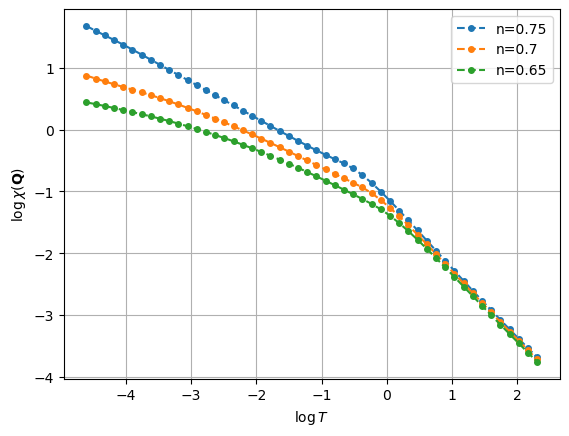

In [5]:
U = 3
n_list = [0.75, 0.7, 0.65]
T_list = np.exp(np.linspace(np.log(0.01), np.log(10), 50))
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard + RPA (U={U}, n={n})'

nk = 100
sweep_dict = [{'par_dict': par_dict, 'nk': nk} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    logT = [np.log(results['par_list'][i]['T']) for i in range(len(results['par_list']))]
    logchi = np.log(1/results['invchi'])
    
    plt.plot(logT, logchi, 'o--', markersize=4, label=f'n={n}')

plt.grid()
plt.legend()
plt.xlabel(r'$\log{T}$')
plt.ylabel(r'$\log{\chi(\mathbf{Q})}$')
plt.show()

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   39.3s finished


4.303775394664265e-09 0.6647243032365018


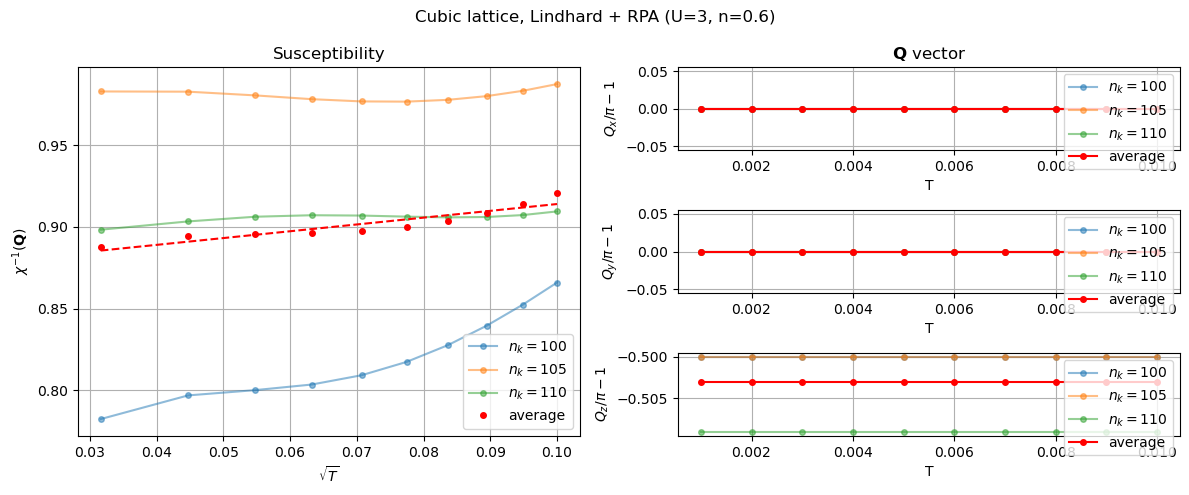

In [ ]:
U = 3
n = 0.6
T_list = np.linspace(1e-4, 1e-2, 5)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard + RPA (U={U}, n={n})'

nk_list = list(range(100, 111, 5))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'refine': True, 'fit': True, 'method': 'lindhard', 'S_iwk_list': [[0.]*1]*len(T_list)} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig, alpha=0.5)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

print(results['Xc'], results['Xc']**results['gamma'])

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:  1.9min remaining:  3.8min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:  1.9min remaining:  1.9min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:  1.9min remaining:   57.9s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:  2.0min finished


n = 0.88 : exp = 1.5941660902889552
n = 0.884 : exp = 2.3234070730966905
n = 0.888 : exp = 3.194127002287518
n = 0.892 : exp = 2.5593295231993776
n = 0.896 : exp = 2.238241811520047
n = 0.9 : exp = 1.9918342142789205


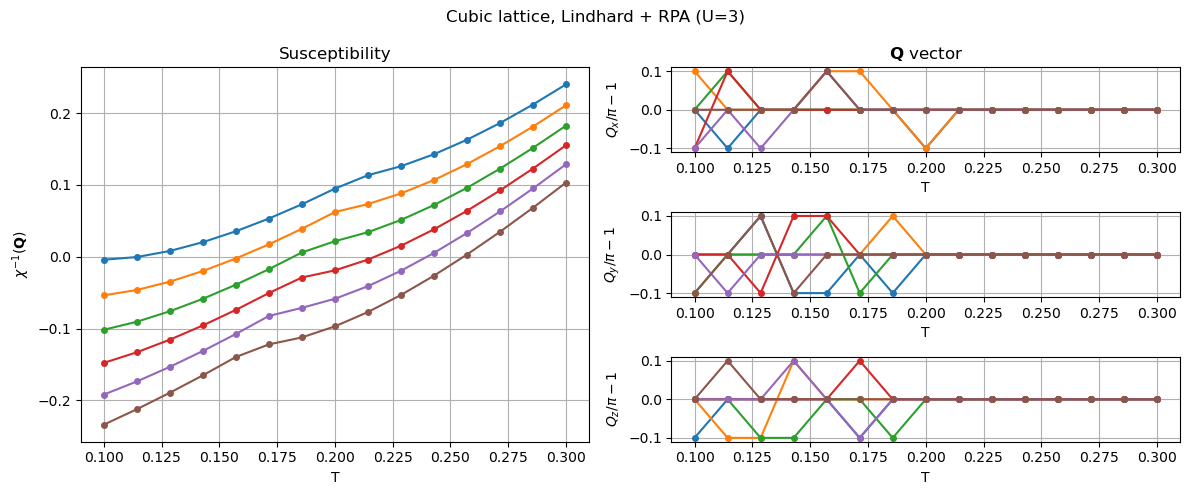

In [19]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 15)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard + RPA (U={U})'

nk = 20
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'n_iw_extr': False, 'refine': False, 'method': 'matsubara_tprf', 'S_iwk_list': [[0.]*512]*len(T_list)} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    gamma = results['gamma']
    print(f'n = {n} : exp = {gamma}')
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig)

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    8.3s remaining:   16.7s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    8.5s remaining:    8.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    8.6s remaining:    4.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    9.0s finished


n = 0.88 : exp = 1.9260057896937957
n = 0.884 : exp = 1.9434715371189153
n = 0.888 : exp = 3.235744463756427
n = 0.892 : exp = 2.811386330553722
n = 0.896 : exp = 2.2534122174321496
n = 0.9 : exp = 2.00333807318507


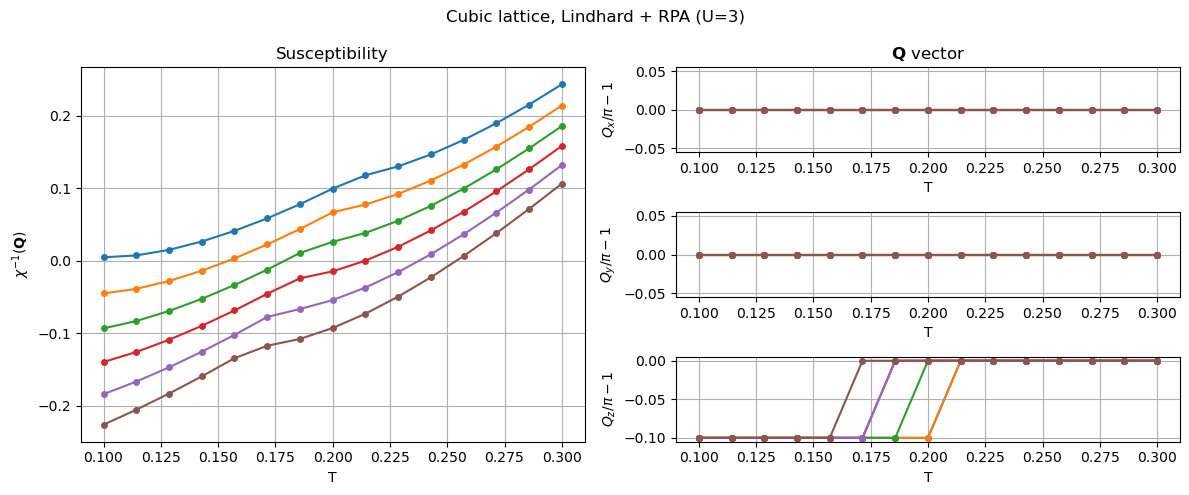

In [18]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 15)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard + RPA (U={U})'

nk = 20
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'n_iw_extr': False, 'refine': False, 'method': 'matsubara', 'S_iwk_list': [[0.]*512]*len(T_list)} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    gamma = results['gamma']
    print(f'n = {n} : exp = {gamma}')
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig)

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-27 09:30:36.578903
Starting serial run at: 2026-04-27 09:30:36.635668
[Parallel(n_jobs=6)]: Done   2 out of   5 | elapsed:   52.5s remaining:  1.3min
[Parallel(n_jobs=6)]: Done   3 out of   5 | elapsed:  2.4min remaining:  1.6min
[Parallel(n_jobs=6)]: Done   5 out of   5 | elapsed:  9.4min finished


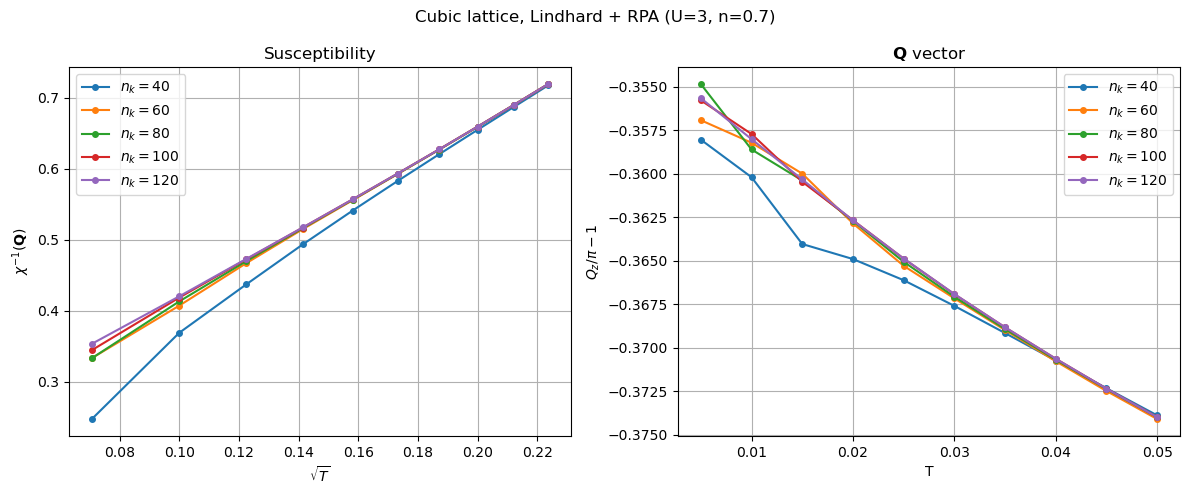

In [45]:
U = 3
n = 0.7
T_list = np.linspace(0.005, 0.05, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard + RPA (U={U}, n={n})'

nk_list = list(range(40, 121, 20))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'nk_avg': (10,1)} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig)

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Starting serial run at: 2026-04-20 22:46:30.029106
Starting serial run at: 2026-04-20 22:46:30.029282
Starting serial run at: 2026-04-20 22:46:30.029284
Starting serial run at: 2026-04-20 22:46:30.043780


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   18.1s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   23.8s remaining:   23.8s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  1.1min finished


Completed 10 jobs in 63.16 seconds | U=3.000, T=0.050, n=0.770
Completed 10 jobs in 1.24 seconds | U=3.000, T=0.050, n=0.770


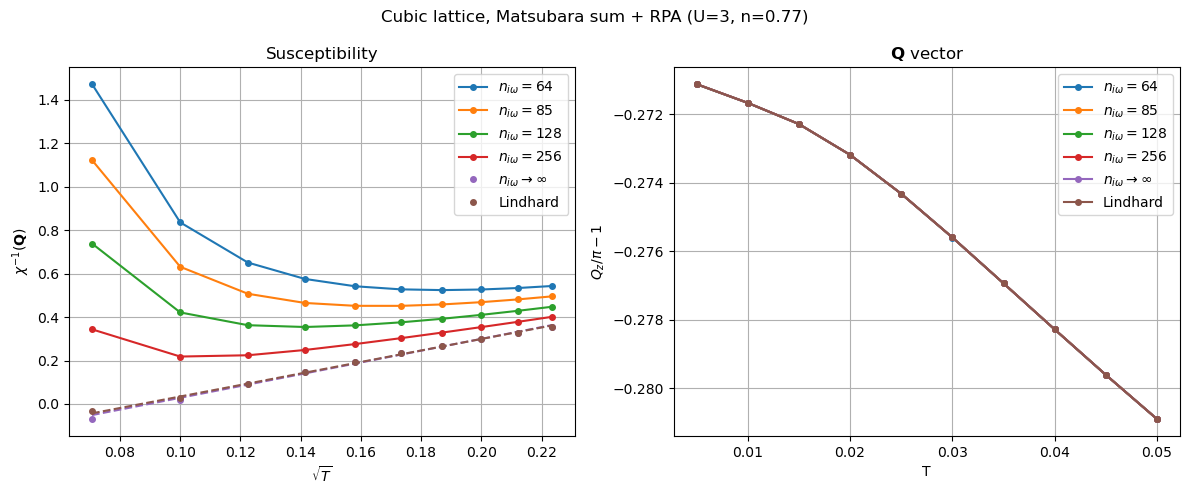

In [8]:
U = 3
n = 0.77
T_list = np.linspace(0.005, 0.05, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 50
n_iw_list = 256//np.array([4,3,2,1])
S_list = [[np.zeros(n_iw) for _ in T_list] for n_iw in n_iw_list]

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iw_list': S_iw_list, 'n_iw_extr': False} for S_iw_list in S_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    n_iw = len(results['S_iw_list'][0])
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={n_iw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, S_iw_list=S_list[-1])
fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk)
fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

In [6]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.01, 6)

nk = 100
fit_list = [critical1, critical2]
fit_label = ['', '_2']
for i, fit_type in enumerate(fit_list):

    file = f'{save_dir}/nTdiag_U3tp0.00{fit_label[i]}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.001)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'fit_type': fit_type, 'nk_avg': (1,1)} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=12, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Starting serial run at: 2026-05-05 13:48:34.678448
Starting serial run at: 2026-05-05 13:48:34.686315
Starting serial run at: 2026-05-05 13:48:34.763909
Starting serial run at: 2026-05-05 13:48:34.810215
Starting serial run at: 2026-05-05 13:48:34.841855


Starting serial run at: 2026-05-05 13:48:34.916178
Starting serial run at: 2026-05-05 13:48:34.923048
Starting serial run at: 2026-05-05 13:48:34.990791
Starting serial run at: 2026-05-05 13:48:35.086963
Starting serial run at: 2026-05-05 13:48:35.106695
Starting serial run at: 2026-05-05 13:48:35.106693


Starting serial run at: 2026-05-05 13:48:35.137307


KeyboardInterrupt: 

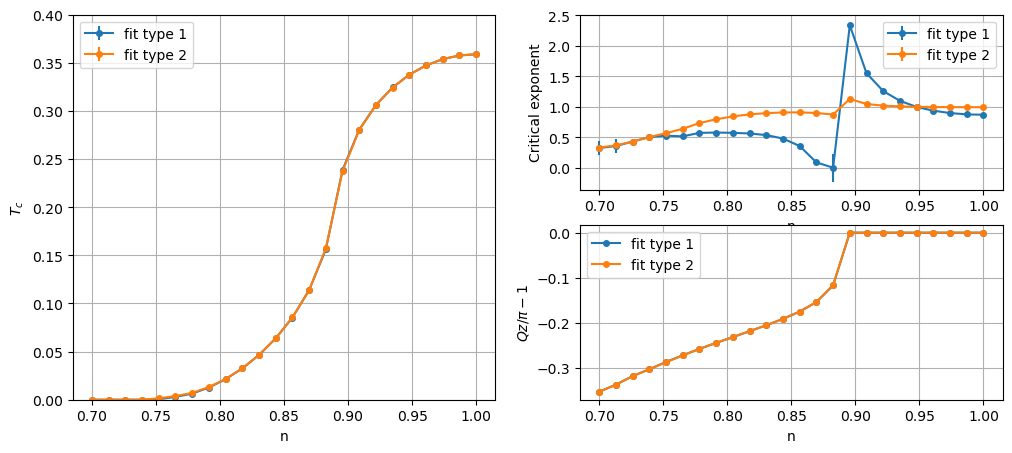

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

fit_list = [critical1, critical2]
fit_label = ['', '_2']
for i, fit_type in enumerate(fit_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp0.00{fit_label[i]}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.01, 6)

nk = 150
tp_list = [0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.001)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-27 01:32:41.323411
Starting serial run at: 2026-04-27 01:32:41.327311
Starting serial run at: 2026-04-27 01:32:41.341519
Starting serial run at: 2026-04-27 01:32:41.349439
Starting serial run at: 2026-04-27 01:32:41.407940
Starting serial run at: 2026-04-27 01:32:41.431446
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  6.1min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  6.2min


Starting serial run at: 2026-04-27 01:44:35.185063


Starting serial run at: 2026-04-27 01:44:47.474923


Starting serial run at: 2026-04-27 01:44:49.062375


...

Starting serial run at: 2026-04-27 02:09:35.680977


Starting serial run at: 2026-04-27 02:09:36.668876


Starting serial run at: 2026-04-27 02:09:41.612553


Starting serial run at: 2026-04-27 02:09:41.995177


Starting serial run at: 2026-04-27 02:09:42.377689
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 17.4min
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 18.6min remaining:  9.3min
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 23.8min remaining:  6.3min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 24.6min remaining:  2.2min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 24.7min finished


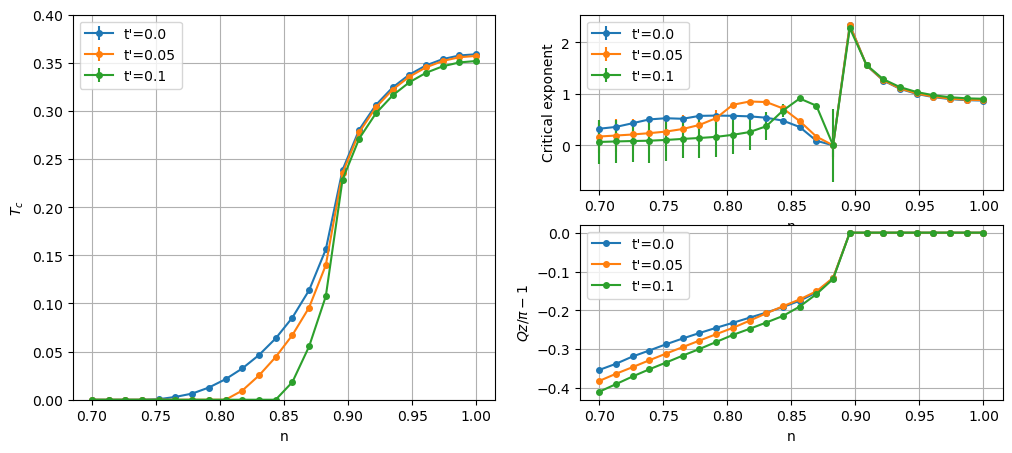

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.01, 6)

nk = 150
tp_list = [-0.05, -0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.001)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-27 02:22:16.737583
Starting serial run at: 2026-04-27 02:22:16.737701
Starting serial run at: 2026-04-27 02:22:16.738658
Starting serial run at: 2026-04-27 02:22:16.765077
Starting serial run at: 2026-04-27 02:22:16.822772
Starting serial run at: 2026-04-27 02:22:16.829023
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  6.2min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  6.3min


Starting serial run at: 2026-04-27 02:34:41.818897


Starting serial run at: 2026-04-27 02:34:42.380213


Starting serial run at: 2026-04-27 02:34:42.802922


...

Starting serial run at: 2026-04-27 02:59:28.182208


Starting serial run at: 2026-04-27 02:59:30.294677


Starting serial run at: 2026-04-27 02:59:34.488952


Starting serial run at: 2026-04-27 02:59:35.970291


Starting serial run at: 2026-04-27 02:59:36.433411
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 17.5min
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 18.5min remaining:  9.3min
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 23.9min remaining:  6.3min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 24.7min remaining:  2.2min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 24.7min finished


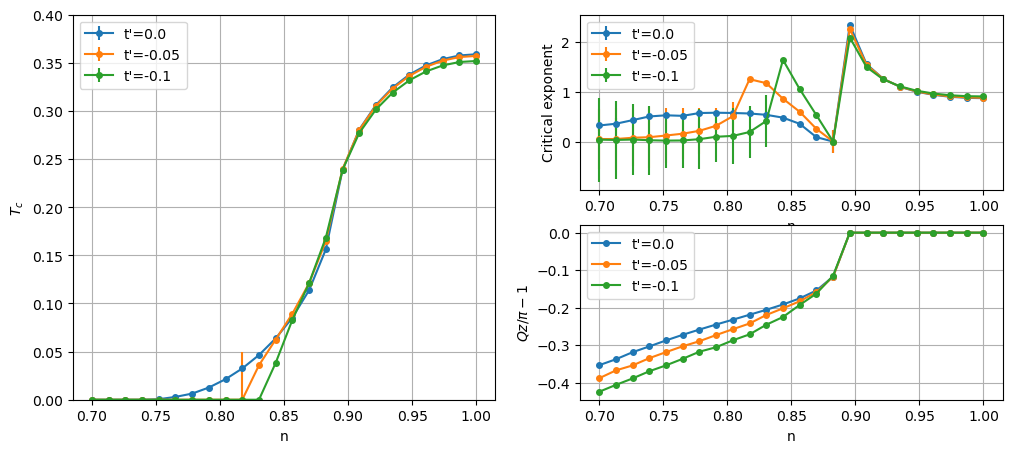

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

tp_list = [0., -0.05, -0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()


plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.01, 6)

nk = 150

Gamma_list = [0., 0.01, 0.025, 0.05]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.001)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 
                   'S_iwk_list': [1j*Gamma_list[i] for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-27 03:12:13.873295
Starting serial run at: 2026-04-27 03:12:13.874813
Starting serial run at: 2026-04-27 03:12:13.916441
Starting serial run at: 2026-04-27 03:12:13.949544
Starting serial run at: 2026-04-27 03:12:13.950203
Starting serial run at: 2026-04-27 03:12:13.970494
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.8min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.9min


Starting serial run at: 2026-04-27 03:23:25.637681


Starting serial run at: 2026-04-27 03:23:31.738524


Starting serial run at: 2026-04-27 03:23:34.419550


...

Starting serial run at: 2026-04-27 04:32:14.238640


Starting serial run at: 2026-04-27 04:32:19.953491


Starting serial run at: 2026-04-27 04:32:22.015293


Starting serial run at: 2026-04-27 04:32:22.618561


Starting serial run at: 2026-04-27 04:32:23.565854
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 16.3min
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 16.8min remaining:  8.4min
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 21.9min remaining:  5.8min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 22.3min remaining:  2.0min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 22.5min finished


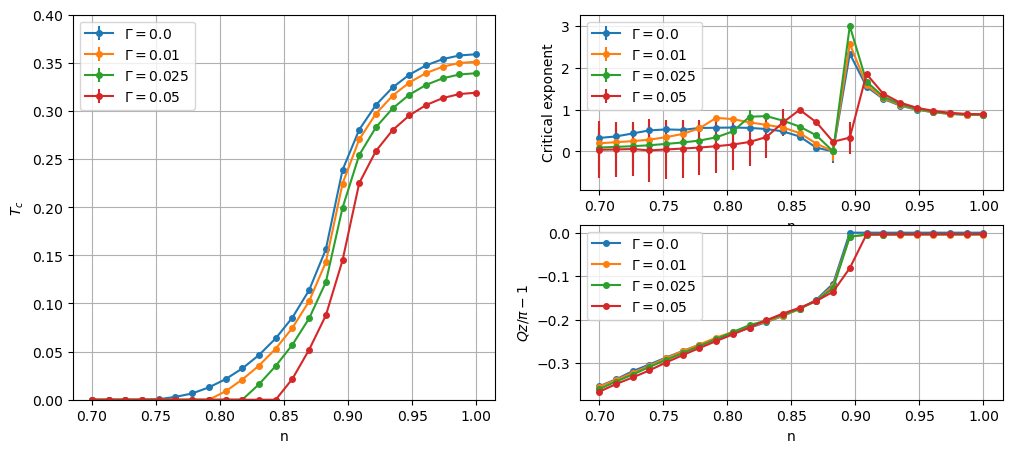

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()